## SECTION 1: IMPORT LIBRARIES


In [1]:
import os
import random
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
from tabulate import tabulate
import cv2

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda import amp
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torchvision.transforms import ColorJitter
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as maskUtils

 ## SECTION 2: CONFIGURATION

In [2]:
# initial dir = /home/somel/code/FYP_Project/Dataset/COCO/masking v1.v1-instance-segmentation-1.coco
ROOT_DIR = "/home/somel/code/FYP_Project/Dataset/COCO/version7.coco.mask"
CHECKPOINT_DIR = "/home/somel/code/FYP_Project/Training_checkpoints/MaskRCNN/maskrcnn_run6"
RESULTS_DIR = "/home/somel/code/FYP_Project/results/maskrcnn_run6"

# Training hyperparameters
BATCH_SIZE = 2
ACCUMULATION_STEPS = 8  # Effective batch size = BATCH_SIZE * ACCUMULATION_STEPS
NUM_EPOCHS = 60
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
NUM_WORKERS = 4

# Create directories
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Device setup
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

print(f"Using device: {device}")

Using device: cuda


## SECTION 3: DATASET PREPARATION

In [3]:
def get_transform_function(train):
    """Apply augmentations for training, basic transform for validation."""
    color_jitter = ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    
    def transform_func(image, target):
        image = F.to_tensor(image)
        if train:
            image = color_jitter(image)
            if random.random() > 0.5:
                image = F.hflip(image)
                width = image.shape[-1]
                height = image.shape[-2]
                for ann in target:
                    # Flip bounding box
                    x, y, w, h = ann['bbox']
                    ann['bbox'] = [width - x - w, y, w, h]
                    
                    # Flip segmentation mask
                    if 'segmentation' in ann and ann['segmentation']:
                        if isinstance(ann['segmentation'], list):
                            # Polygon format
                            new_seg = []
                            for seg in ann['segmentation']:
                                new_poly = []
                                for i in range(0, len(seg), 2):
                                    new_poly.append(width - seg[i])
                                    new_poly.append(seg[i + 1])
                                new_seg.append(new_poly)
                            ann['segmentation'] = new_seg
                        else:
                            # RLE format - Decode -> Flip -> Store as Mask
                            mask = polygons_to_mask(ann['segmentation'], height, width)
                            mask = np.fliplr(mask)
                            # Store as numpy array - process_target must handle this
                            ann['segmentation'] = mask
        return image, target
    return transform_func

def polygons_to_mask(segmentation, height, width):
    """Convert COCO polygon segmentation or RLE to binary mask."""
    if isinstance(segmentation, (np.ndarray, torch.Tensor)):
        return np.array(segmentation)

    if not segmentation:
        return np.zeros((height, width), dtype=np.uint8)
    
    if isinstance(segmentation, list):
        # Polygon format: list of lists of coordinates
        rles = maskUtils.frPyObjects(segmentation, height, width)
        rle = maskUtils.merge(rles)
    elif isinstance(segmentation, dict):
        # RLE format
        if isinstance(segmentation['counts'], list):
            # Uncompressed RLE
            rle = maskUtils.frPyObjects(segmentation, height, width)
        else:
            # Compressed RLE (string) - use as is
            rle = segmentation
    else:
        return np.zeros((height, width), dtype=np.uint8)
    
    mask = maskUtils.decode(rle)
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]  # Ensure 2D mask
    return mask

def process_target(target, image_size, coco_id_mapping=None):
    """Convert COCO annotations to Mask R-CNN format with masks and ID remapping."""
    boxes, labels, masks = [], [], []
    height, width = image_size
    
    for ann in target:
        x, y, w, h = ann['bbox']
        if w > 0 and h > 0:
            boxes.append([x, y, x + w, y + h])
            
            # Remap COCO category_id to model label if mapping provided
            if coco_id_mapping is not None:
                labels.append(coco_id_mapping[ann['category_id']])
            else:
                labels.append(ann['category_id'])
            
            # Convert segmentation to binary mask (MOVED OUTSIDE of else block!)
            if 'segmentation' in ann:
                seg = ann['segmentation']
                has_seg = False
                if isinstance(seg, (np.ndarray, torch.Tensor)):
                    has_seg = seg.size > 0
                elif seg:  # list or dict
                    has_seg = True
                
                if has_seg:
                    mask = polygons_to_mask(seg, height, width)
                else:
                    # Fallback: create mask from bounding box if no segmentation
                    mask = np.zeros((height, width), dtype=np.uint8)
                    mask[int(y):int(y+h), int(x):int(x+w)] = 1
            else:
                # Fallback: create mask from bounding box if no segmentation
                mask = np.zeros((height, width), dtype=np.uint8)
                mask[int(y):int(y+h), int(x):int(x+w)] = 1
            masks.append(mask)
    
    if not boxes:
        boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)
        masks = torch.zeros((0, height, width), dtype=torch.uint8)
    else:
        boxes = torch.tensor(boxes, dtype=torch.float32).view(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)
        masks = torch.tensor(np.array(masks), dtype=torch.uint8)
    
    return {'boxes': boxes, 'labels': labels, 'masks': masks}

## SECTION 4: DATA SPLITTING / LOADING

In [4]:
print("Setting up Data Loaders...")
train_images_dir = os.path.join(ROOT_DIR, "train")
train_ann_file = os.path.join(ROOT_DIR, "train", "_annotations.coco.json")
val_images_dir = os.path.join(ROOT_DIR, "valid")
val_ann_file = os.path.join(ROOT_DIR, "valid", "_annotations.coco.json")

train_dataset = CocoDetection(root=train_images_dir, annFile=train_ann_file,
                              transforms=get_transform_function(train=True))
val_dataset = CocoDetection(root=val_images_dir, annFile=val_ann_file,
                            transforms=get_transform_function(train=False))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, collate_fn=lambda x: tuple(zip(*x)))

# Load COCO ground truth for evaluation
coco_gt = COCO(val_ann_file)

# Build dynamic mapping: COCO category_id -> model label (1-indexed)
coco_categories = coco_gt.loadCats(coco_gt.getCatIds())
sorted_categories = sorted(coco_categories, key=lambda x: x['id'])
COCO_ID_TO_MODEL_LABEL = {cat['id']: idx + 1 for idx, cat in enumerate(sorted_categories)}
MODEL_LABEL_TO_COCO_ID = {v: k for k, v in COCO_ID_TO_MODEL_LABEL.items()}  # ← ADD THIS LINE
MODEL_LABEL_TO_NAME = {idx + 1: cat['name'] for idx, cat in enumerate(sorted_categories)}
CLASS_NAMES = [cat['name'] for cat in sorted_categories]

# Update NUM_CLASSES dynamically (background + actual classes)
NUM_CLASSES = len(CLASS_NAMES) + 1
print(f"COCO ID -> Model Label: {COCO_ID_TO_MODEL_LABEL}")
print(f"Classes: {CLASS_NAMES}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

Setting up Data Loaders...
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
COCO ID -> Model Label: {0: 1, 1: 2, 2: 3, 3: 4}
Classes: ['fish-zKdm-lP6L-Cisr', 'Groupers', 'Seabass', 'Tilapia']
NUM_CLASSES: 5


## SECTION 5: MODEL SETUP

In [5]:
print(f"Loading Mask R-CNN ResNet50-FPN with {NUM_CLASSES} classes...")
model = maskrcnn_resnet50_fpn(pretrained=True)

# Replace box predictor
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, NUM_CLASSES)

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, NUM_CLASSES)

model.to(device)

# Optimizer with SGD
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Adaptive LR scheduler - reduces LR when validation mAP plateaus (Dynamic Learning Rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Mixed precision scaler
scaler = amp.GradScaler()

# Training history
history = {
    'train_loss': [],
    'loss_classifier': [], 'loss_box_reg': [], 'loss_objectness': [], 'loss_rpn_box_reg': [], 'loss_mask': [],
    'precision': [], 'recall': [], 
    'box_mAP50': [], 'box_mAP50-95': [],
    'mask_mAP50': [], 'mask_mAP50-95': [],
    'lr': [], 'epoch_time':[]
}


Loading Mask R-CNN ResNet50-FPN with 5 classes...


/home/somel/code/FYP_Project/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/somel/code/FYP_Project/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_1924/1156008722.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


## SECTION 6: CHECKPOINT RESUME

In [6]:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if 'history' in checkpoint:
        history = checkpoint['history']
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from Epoch {start_epoch}")

Loading checkpoint from /home/somel/code/FYP_Project/Training_checkpoints/MaskRCNN/maskrcnn_run6/last_checkpoint.pth...
Resuming from Epoch 60


## SECTION 7: EVALUATION FUNCTIONS

In [7]:
def collect_predictions(model, loader, device, conf_thresh=0.001):
    """Collect all predictions and ground truths for evaluation."""
    model.eval()
    all_preds = []
    all_gts = []
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]
            outputs = model(images)
            
            for i, output in enumerate(outputs):
                dataset_idx = batch_idx * loader.batch_size + i
                if dataset_idx >= len(loader.dataset):
                    continue
                image_id = loader.dataset.ids[dataset_idx]
                
                # Predictions
                boxes = output['boxes'].cpu().numpy()
                labels = output['labels'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                
                for j in range(len(boxes)):
                    if scores[j] >= conf_thresh:
                        all_preds.append({
                            'image_id': image_id, 'class_id': int(labels[j]),
                            'confidence': float(scores[j]), 'box': boxes[j].tolist()
                        })
                
                # Ground truths
                img_info = loader.dataset.coco.loadImgs(image_id)[0]
                image_size = (img_info['height'], img_info['width'])
                gt = process_target(targets[i], image_size, COCO_ID_TO_MODEL_LABEL)
                gt_boxes = gt['boxes'].numpy()
                gt_labels = gt['labels'].numpy()
                for j in range(len(gt_boxes)):
                    all_gts.append({
                        'image_id': image_id, 'class_id': int(gt_labels[j]),
                        'box': gt_boxes[j].tolist()
                    })
    
    return all_preds, all_gts

def compute_iou(box1, box2):
    """Compute IoU between two boxes [x1, y1, x2, y2]."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    
    return inter / union if union > 0 else 0

def compute_metrics_at_threshold(preds, gts, conf_thresh, iou_thresh=0.5):
    """Compute precision, recall, F1 at a specific confidence threshold."""
    filtered_preds = [p for p in preds if p['confidence'] >= conf_thresh]
    
    gt_by_img_cls = defaultdict(list)
    for gt in gts:
        gt_by_img_cls[(gt['image_id'], gt['class_id'])].append(gt)
    
    tp, fp, total_gt = 0, 0, len(gts)
    matched_gts = set()
    
    filtered_preds = sorted(filtered_preds, key=lambda x: -x['confidence'])
    
    for pred in filtered_preds:
        key = (pred['image_id'], pred['class_id'])
        best_iou, best_gt_idx = 0, -1
        
        for idx, gt in enumerate(gt_by_img_cls[key]):
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx
        
        gt_key = (key[0], key[1], best_gt_idx)
        if best_iou >= iou_thresh and gt_key not in matched_gts:
            tp += 1
            matched_gts.add(gt_key)
        else:
            fp += 1
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_gt if total_gt > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

def compute_ap(preds, gts, class_id, iou_thresh=0.5):
    """Compute Average Precision for a single class."""
    class_preds = [p for p in preds if p['class_id'] == class_id]
    class_gts = [g for g in gts if g['class_id'] == class_id]
    
    if not class_gts:
        return 0.0, [], []
    
    class_preds = sorted(class_preds, key=lambda x: -x['confidence'])
    
    gt_by_img = defaultdict(list)
    for gt in class_gts:
        gt_by_img[gt['image_id']].append(gt)
    
    tp_list, fp_list = [], []
    matched = set()
    
    for pred in class_preds:
        img_gts = gt_by_img[pred['image_id']]
        best_iou, best_idx = 0, -1
        
        for idx, gt in enumerate(img_gts):
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou
                best_idx = idx
        
        key = (pred['image_id'], best_idx)
        if best_iou >= iou_thresh and key not in matched:
            tp_list.append(1)
            fp_list.append(0)
            matched.add(key)
        else:
            tp_list.append(0)
            fp_list.append(1)
    
    if not tp_list:
        return 0.0, [], []
    
    tp_cumsum = np.cumsum(tp_list)
    fp_cumsum = np.cumsum(fp_list)
    
    recalls = tp_cumsum / len(class_gts)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    
    # Compute AP using 11-point interpolation
    ap = 0
    for t in np.linspace(0, 1, 11):
        prec_at_recall = precisions[recalls >= t]
        ap += prec_at_recall.max() if len(prec_at_recall) > 0 else 0
    ap /= 11
    
    return ap, recalls, precisions

def validate_epoch(model, loader, coco_gt, device):
    """Run COCO evaluation for both boxes and masks, return mAP values."""
    model.eval()
    box_predictions = []
    mask_predictions = []
    
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]
            outputs = model(images)
            
            for i, output in enumerate(outputs):
                dataset_idx = batch_idx * loader.batch_size + i
                if dataset_idx >= len(loader.dataset):
                    continue
                image_id = loader.dataset.ids[dataset_idx]
                
                boxes = output['boxes'].cpu().numpy()
                labels = output['labels'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                masks = output['masks'].cpu().numpy()
                
                for j in range(len(boxes)):
                    x1, y1, x2, y2 = boxes[j]
                    
                    # Box predictions
                    box_predictions.append({
                        'image_id': int(image_id), 'category_id': MODEL_LABEL_TO_COCO_ID.get(int(labels[j]), int(labels[j])),
                        'bbox': [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                        'score': float(scores[j])
                    })
                    
                    # Mask predictions (convert to RLE)
                    mask = masks[j, 0] > 0.5  # Threshold mask
                    rle = maskUtils.encode(np.asfortranarray(mask.astype(np.uint8)))
                    rle['counts'] = rle['counts'].decode('utf-8')
                    mask_predictions.append({
                        'image_id': int(image_id), 'category_id': MODEL_LABEL_TO_COCO_ID.get(int(labels[j]), int(labels[j])),
                        'segmentation': rle,
                        'score': float(scores[j])
                    })
    
    # Default values
    box_mAP50, box_mAP50_95 = 0.0, 0.0
    mask_mAP50, mask_mAP50_95 = 0.0, 0.0
    precision, recall = 0.0, 0.0
    
    if box_predictions:
        # Box evaluation
        coco_dt_box = coco_gt.loadRes(box_predictions)
        coco_eval_box = COCOeval(coco_gt, coco_dt_box, 'bbox')
        coco_eval_box.params.imgIds = loader.dataset.ids
        coco_eval_box.evaluate()
        coco_eval_box.accumulate()
        coco_eval_box.summarize()
        box_mAP50 = coco_eval_box.stats[1]
        box_mAP50_95 = coco_eval_box.stats[0]
    
    if mask_predictions:
        # Mask evaluation
        coco_dt_mask = coco_gt.loadRes(mask_predictions)
        coco_eval_mask = COCOeval(coco_gt, coco_dt_mask, 'segm')
        coco_eval_mask.params.imgIds = loader.dataset.ids
        coco_eval_mask.evaluate()
        coco_eval_mask.accumulate()
        coco_eval_mask.summarize()
        mask_mAP50 = coco_eval_mask.stats[1]
        mask_mAP50_95 = coco_eval_mask.stats[0]
    
    # Estimate precision/recall at IoU=0.5, conf=0.5
    preds, gts = collect_predictions(model, loader, device, conf_thresh=0.5)
    precision, recall, _ = compute_metrics_at_threshold(preds, gts, conf_thresh=0.5)
    
    return box_mAP50, box_mAP50_95, mask_mAP50, mask_mAP50_95, precision, recall


## SECTION 8: PLOTTING FUNCTIONS

In [8]:
def save_training_dashboard(history, save_dir):
    """Generate YOLO-style training dashboard with 12 subplots."""
    fig, axes = plt.subplots(3, 4, figsize=(20, 8))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Row 1: Training losses
    axes[0, 0].plot(epochs, history['loss_box_reg'], 'b.-')
    axes[0, 0].set_title('train/box_loss')
    axes[0, 0].set_xlabel('Epoch')
    
    axes[0, 1].plot(epochs, history['loss_classifier'], 'b.-')
    axes[0, 1].set_title('train/cls_loss')
    axes[0, 1].set_xlabel('Epoch')
    
    axes[0, 2].plot(epochs, history['loss_objectness'], 'b.-')
    axes[0, 2].set_title('train/obj_loss')
    axes[0, 2].set_xlabel('Epoch')
    
    axes[0, 3].plot(epochs, history['loss_mask'], 'b.-')
    axes[0, 3].set_title('train/mask_loss')
    axes[0, 3].set_xlabel('Epoch')
    
    # Row 2: More losses and LR
    axes[1, 0].plot(epochs, history['loss_rpn_box_reg'], 'b.-')
    axes[1, 0].set_title('train/rpn_box_loss')
    axes[1, 0].set_xlabel('Epoch')
    
    axes[1, 1].plot(epochs, history['train_loss'], 'b.-')
    axes[1, 1].set_title('train/total_loss')
    axes[1, 1].set_xlabel('Epoch')
    
    axes[1, 2].plot(epochs, history['lr'], 'b.-')
    axes[1, 2].set_title('learning_rate')
    axes[1, 2].set_xlabel('Epoch')
    
    axes[1, 3].plot(epochs, history['precision'], 'b.-')
    axes[1, 3].set_title('metrics/precision')
    axes[1, 3].set_xlabel('Epoch')
    
    # Row 3: Validation metrics
    axes[2, 0].plot(epochs, history['recall'], 'b.-')
    axes[2, 0].set_title('metrics/recall')
    axes[2, 0].set_xlabel('Epoch')
    
    axes[2, 1].plot(epochs, history['box_mAP50'], 'b.-')
    axes[2, 1].set_title('metrics/box_mAP50')
    axes[2, 1].set_xlabel('Epoch')
    
    axes[2, 2].plot(epochs, history['mask_mAP50'], 'b.-')
    axes[2, 2].set_title('metrics/mask_mAP50')
    axes[2, 2].set_xlabel('Epoch')
    
    axes[2, 3].plot(epochs, history['mask_mAP50-95'], 'b.-')
    axes[2, 3].set_title('metrics/mask_mAP50-95')
    axes[2, 3].set_xlabel('Epoch')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'results.png'), dpi=150)
    plt.close()

def save_pr_curve(preds, gts, class_names, save_dir):
    """Save Precision-Recall curve per class."""
    plt.figure(figsize=(10, 8))
    
    class_ids = sorted(set(g['class_id'] for g in gts))
    all_aps = []
    
    for cls_id in class_ids:
        ap, recalls, precisions = compute_ap(preds, gts, cls_id)
        all_aps.append(ap)
        cls_name = MODEL_LABEL_TO_NAME.get(cls_id, f"Class {cls_id}")
        if len(recalls) > 0:
            plt.plot(recalls, precisions, label=f'{cls_name} {ap:.3f}', linewidth=1.5)
    
    mean_ap = np.mean(all_aps) if all_aps else 0
    plt.plot([0, 1], [mean_ap, mean_ap], 'b-', linewidth=2.5, label=f'all classes {mean_ap:.3f} mAP@0.5')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'PR_curve.png'), dpi=150)
    plt.close()

def save_confidence_curves(preds, gts, class_names, save_dir):
    """Save P-Conf, R-Conf, F1-Conf curves."""
    conf_thresholds = np.linspace(0, 1, 101)
    class_ids = sorted(set(g['class_id'] for g in gts))
    
    class_metrics = {cls_id: {'precision': [], 'recall': [], 'f1': []} for cls_id in class_ids}
    all_metrics = {'precision': [], 'recall': [], 'f1': []}
    
    for conf in conf_thresholds:
        p, r, f = compute_metrics_at_threshold(preds, gts, conf)
        all_metrics['precision'].append(p)
        all_metrics['recall'].append(r)
        all_metrics['f1'].append(f)
        
        for cls_id in class_ids:
            cls_preds = [p for p in preds if p['class_id'] == cls_id]
            cls_gts = [g for g in gts if g['class_id'] == cls_id]
            p, r, f = compute_metrics_at_threshold(cls_preds, cls_gts, conf)
            class_metrics[cls_id]['precision'].append(p)
            class_metrics[cls_id]['recall'].append(r)
            class_metrics[cls_id]['f1'].append(f)
    
    # Precision-Confidence Curve
    plt.figure(figsize=(10, 8))
    for cls_id in class_ids:
        cls_name = MODEL_LABEL_TO_NAME.get(cls_id, f"Class {cls_id}")
        plt.plot(conf_thresholds, class_metrics[cls_id]['precision'], label=cls_name, linewidth=1.5)
    best_idx = np.argmax(all_metrics['precision'])
    plt.plot(conf_thresholds, all_metrics['precision'], 'b-', linewidth=2.5, 
             label=f'all classes {all_metrics["precision"][best_idx]:.2f} at {conf_thresholds[best_idx]:.3f}')
    plt.xlabel('Confidence')
    plt.ylabel('Precision')
    plt.title('Precision-Confidence Curve')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'P_curve.png'), dpi=150)
    plt.close()
    
    # Recall-Confidence Curve
    plt.figure(figsize=(10, 8))
    for cls_id in class_ids:
        cls_name = MODEL_LABEL_TO_NAME.get(cls_id, f"Class {cls_id}")
        plt.plot(conf_thresholds, class_metrics[cls_id]['recall'], label=cls_name, linewidth=1.5)
    best_idx = np.argmax(all_metrics['recall'])
    plt.plot(conf_thresholds, all_metrics['recall'], 'b-', linewidth=2.5,
             label=f'all classes {all_metrics["recall"][best_idx]:.2f} at {conf_thresholds[best_idx]:.3f}')
    plt.xlabel('Confidence')
    plt.ylabel('Recall')
    plt.title('Recall-Confidence Curve')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'R_curve.png'), dpi=150)
    plt.close()
    
    # F1-Confidence Curve
    plt.figure(figsize=(10, 8))
    for cls_id in class_ids:
        cls_name = MODEL_LABEL_TO_NAME.get(cls_id, f"Class {cls_id}")
        plt.plot(conf_thresholds, class_metrics[cls_id]['f1'], label=cls_name, linewidth=1.5)
    best_idx = np.argmax(all_metrics['f1'])
    plt.plot(conf_thresholds, all_metrics['f1'], 'b-', linewidth=2.5,
             label=f'all classes {all_metrics["f1"][best_idx]:.2f} at {conf_thresholds[best_idx]:.3f}')
    plt.xlabel('Confidence')
    plt.ylabel('F1')
    plt.title('F1-Confidence Curve')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'F1_curve.png'), dpi=150)
    plt.close()

def compute_confusion_matrix_no_bg(model, loader, device, num_classes, class_names,
                                   iou_threshold=0.5, conf_thresh=0.5):
    """
    Compute confusion matrix with a background column/row for FP and FN.
    Rows = Ground Truth (actual), Columns = Predicted.
    Last row/col = background (for FN and FP respectively).
    """
    model.eval()
    num_real = num_classes - 1  # exclude model's background label (0)

    # Size: (num_real + 1) x (num_real + 1)
    # Last row = FN (GT unmatched), Last col = FP (Pred unmatched)
    cm = np.zeros((num_real + 1, num_real + 1), dtype=np.int64)
    bg_idx = num_real  # index for the background row/col

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, output in enumerate(outputs):
                # Get image size from the tensor
                img_height, img_width = images[i].shape[1], images[i].shape[2]
                gt = process_target(targets[i], (img_height, img_width), COCO_ID_TO_MODEL_LABEL)
                gt_boxes  = gt['boxes'].to(device)
                gt_labels = gt['labels'].to(device)

                pred_boxes  = output['boxes']
                pred_labels = output['labels']
                pred_scores = output['scores']

                # Filter predictions by confidence  ← FIX: use conf_thresh
                keep = pred_scores > conf_thresh
                pred_boxes  = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                matched_gt_indices   = set()
                matched_pred_indices = set()

                # --- Match GTs to Predictions (greedy, highest-IoU first) ---
                if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                    ious = torchvision.ops.box_iou(gt_boxes, pred_boxes)  # [num_gt, num_pred]

                    for g_idx in range(len(gt_boxes)):
                        iou_row = ious[g_idx].clone()

                        # Mask already-used predictions so they can't be matched again ← FIX
                        for used in matched_pred_indices:
                            iou_row[used] = 0.0

                        best_iou, best_p_idx = iou_row.max(dim=0)

                        if best_iou >= iou_threshold:
                            matched_gt_indices.add(g_idx)
                            matched_pred_indices.add(best_p_idx.item())

                            g_lab = gt_labels[g_idx].item() - 1   # convert to 0-indexed
                            p_lab = pred_labels[best_p_idx].item() - 1

                            if 0 <= g_lab < num_real and 0 <= p_lab < num_real:
                                cm[g_lab, p_lab] += 1  # TP or class confusion

                # --- Unmatched GTs = False Negatives (last column) ---   ← FIX
                for g_idx in range(len(gt_boxes)):
                    if g_idx not in matched_gt_indices:
                        g_lab = gt_labels[g_idx].item() - 1
                        if 0 <= g_lab < num_real:
                            cm[g_lab, bg_idx] += 1  # FN

                # --- Unmatched Predictions = False Positives (last row) ---  ← FIX
                for p_idx in range(len(pred_boxes)):
                    if p_idx not in matched_pred_indices:
                        p_lab = pred_labels[p_idx].item() - 1
                        if 0 <= p_lab < num_real:
                            cm[bg_idx, p_lab] += 1  # FP

    return cm



def save_confusion_matrix(cm, class_names, save_dir, include_background=True):
    """Save confusion matrix heatmap."""
    if include_background:
        display_names = list(class_names) + ['Background\n(FP/FN)']
    else:
        display_names = list(class_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=display_names,   # Predicted
                yticklabels=display_names)   # Ground Truth
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Confusion Matrix\n(Last row/col = unmatched FP/FN)')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=150)
    plt.close()

def save_metrics_table(history, preds, gts, class_names, save_dir,
                       coco_box_mAP50=None, class_ids_to_show=None):
    """Save metrics summary table."""
    class_ids = sorted(set(g['class_id'] for g in gts))

    # Filter to only the requested classes if specified  ← FIX
    if class_ids_to_show is not None:
        class_ids = [c for c in class_ids if c in class_ids_to_show]

    table_data = []
    for cls_id in class_ids:
        cls_name = MODEL_LABEL_TO_NAME.get(cls_id, f"Class {cls_id}")
        ap, _, _ = compute_ap(preds, gts, cls_id)

        cls_preds = [p for p in preds if p['class_id'] == cls_id]
        cls_gts   = [g for g in gts   if g['class_id'] == cls_id]
        p, r, f1  = compute_metrics_at_threshold(cls_preds, cls_gts, 0.5)

        table_data.append([cls_name, f"{p:.4f}", f"{r:.4f}", f"{f1:.4f}", f"{ap:.4f}"])

    # Overall row — always use same 11-pt AP method for consistency  ← FIX
    all_aps  = [compute_ap(preds, gts, c)[0] for c in class_ids]
    mean_ap  = np.mean(all_aps) if all_aps else 0.0

    # Filter preds/gts to only the kept classes for the overall row too
    filtered_preds = [p for p in preds if p['class_id'] in class_ids]
    filtered_gts   = [g for g in gts   if g['class_id'] in class_ids]
    overall_p, overall_r, overall_f1 = compute_metrics_at_threshold(filtered_preds, filtered_gts, 0.5)

    table_data.append(['Overall', f"{overall_p:.4f}", f"{overall_r:.4f}", f"{overall_f1:.4f}", f"{mean_ap:.4f}"])

    headers = ['Class', 'Precision', 'Recall', 'F1', 'mAP@0.5']

    # Print to console
    print("\n" + "="*60)
    print("METRICS SUMMARY")
    print("="*60)
    print(tabulate(table_data, headers=headers, tablefmt='grid'))

    # Print COCO mAP separately as a reference (different methodology)  ← FIX
    if coco_box_mAP50 is not None:
        print(f"\n[Reference] COCO box mAP@0.5 (pycocotools, last epoch): {coco_box_mAP50:.4f}")

    # Save to CSV
    df = pd.DataFrame(table_data, columns=headers)
    df.to_csv(os.path.join(save_dir, 'metrics_summary.csv'), index=False)

    # Training summary
    if history['train_loss']:
        print(f"\nFinal Training Loss:     {history['train_loss'][-1]:.4f}")
        print(f"Final Box mAP@0.5:       {history['box_mAP50'][-1]:.4f}")
        print(f"Final Mask mAP@0.5:      {history['mask_mAP50'][-1]:.4f}")
        print(f"Final Mask mAP@0.5:0.95: {history['mask_mAP50-95'][-1]:.4f}")


def save_results_csv(history, save_dir):
    """Save training history to CSV (YOLO-style results.csv)."""
    filtered_history = {k: v for k, v in history.items() if len(v) > 0}
    df = pd.DataFrame(filtered_history)
    df.index.name = 'epoch'
    df.to_csv(os.path.join(save_dir, 'results.csv'))

## SECTION 9: TRAINING LOOP

In [9]:
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
training_start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start_time = time.time()
    model.train()
    epoch_loss = 0.0
    running_losses = {
        'loss_classifier': 0.0, 'loss_box_reg': 0.0,
        'loss_objectness': 0.0, 'loss_rpn_box_reg': 0.0, 'loss_mask': 0.0
    }
    
    optimizer.zero_grad()
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        # Learning rate warmup for first epoch
        if epoch == 0 and batch_idx < 500:
            lr_factor = (batch_idx + 1) / 500
            for pg in optimizer.param_groups:
                pg['lr'] = lr_factor * LEARNING_RATE
        
        # Get image sizes and process targets
        processed_targets = []
        for i, t in enumerate(targets):
            img_height, img_width = images[i].shape[1], images[i].shape[2]
            processed_targets.append(process_target(t, (img_height, img_width), COCO_ID_TO_MODEL_LABEL))
        
        images = [img.to(device) for img in images]
        targets_device = [{k: v.to(device) for k, v in t.items()} for t in processed_targets]
        
        with amp.autocast():
            loss_dict = model(images, targets_device)
            losses = sum(loss for loss in loss_dict.values())
        
        # Gradient accumulation
        loss_accum = losses / ACCUMULATION_STEPS
        scaler.scale(loss_accum).backward()
        
        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        epoch_loss += losses.item()
        for k, v in loss_dict.items():
            if k in running_losses:
                running_losses[k] += v.item()
        
        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Batch {batch_idx}, Loss: {losses.item():.4f}, LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} Complete - Avg Loss: {avg_epoch_loss:.4f} - Time: {epoch_time:.1f}s")

    
    # Save training losses
    history['train_loss'].append(avg_epoch_loss)
    history['lr'].append(current_lr)
    history['epoch_time'].append(epoch_time)
    for k in running_losses:
        history[k].append(running_losses[k] / len(train_loader))
    
    # Validation
    print("Running validation...")
    box_mAP50, box_mAP50_95, mask_mAP50, mask_mAP50_95, precision, recall = validate_epoch(model, val_loader, coco_gt, device)
    history['box_mAP50'].append(box_mAP50)
    history['box_mAP50-95'].append(box_mAP50_95)
    history['mask_mAP50'].append(mask_mAP50)
    history['mask_mAP50-95'].append(mask_mAP50_95)
    history['precision'].append(precision)
    history['recall'].append(recall)
    
    print(f"Box mAP@0.5: {box_mAP50:.4f}, Box mAP@0.5:0.95: {box_mAP50_95:.4f}")
    print(f"Mask mAP@0.5: {mask_mAP50:.4f}, Mask mAP@0.5:0.95: {mask_mAP50_95:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
    
    # Update scheduler based on mask mAP (Dynamic Learning Rate)
    scheduler.step(mask_mAP50)
    
    # Save checkpoint
    checkpoint_data = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'loss': avg_epoch_loss
    }
    torch.save(checkpoint_data, CHECKPOINT_PATH)
    
    # Save best model based on mask mAP
    if mask_mAP50 >= max(history['mask_mAP50']):
        torch.save(checkpoint_data, os.path.join(CHECKPOINT_DIR, 'best.pth'))
        print("New best model saved!")
    
    # Save training dashboard and CSV after each epoch
    save_training_dashboard(history, RESULTS_DIR)
    save_results_csv(history, RESULTS_DIR)
    
    print(f"Checkpoint saved for Epoch {epoch+1}\n")

total_training_time = time.time() - training_start_time
hours = int(total_training_time // 3600)
minutes = int((total_training_time % 3600) // 60)
seconds = int(total_training_time % 60)
print(f"\nTotal Training Time: {hours}h {minutes}m {seconds}s")



STARTING TRAINING

Total Training Time: 0h 0m 0s


## SECTION 10: FINAL EVALUATION

In [10]:
print("\n" + "="*60)
print("TRAINING COMPLETE - FINAL EVALUATION")
print("="*60)

# ── 1. Collect predictions ───────────────────────────────────────────────────
print("Collecting predictions for evaluation curves...")
preds, gts = collect_predictions(model, val_loader, device)

# ── 2. Define which classes to keep (must match in BOTH CM and table) ────────
CLASSES_TO_KEEP  = ['Groupers', 'Seabass', 'Tilapia']
keep_indices     = [i for i, name in enumerate(CLASS_NAMES) if name in CLASSES_TO_KEEP]
filtered_class_names = [CLASS_NAMES[i] for i in keep_indices]

# Class IDs (model label space, 1-indexed) for the kept classes
keep_class_ids = [cls_id for cls_id, name in MODEL_LABEL_TO_NAME.items() if name in CLASSES_TO_KEEP]
print(f"Keeping classes: {filtered_class_names}")
print(f"Corresponding class IDs: {keep_class_ids}")

# ── 3. PR curve ──────────────────────────────────────────────────────────────
print("Generating Precision-Recall curve...")
save_pr_curve(preds, gts, CLASS_NAMES, RESULTS_DIR)

# ── 4. Confidence curves ─────────────────────────────────────────────────────
print("Generating confidence curves...")
save_confidence_curves(preds, gts, CLASS_NAMES, RESULTS_DIR)

# ── 5. Confusion matrix ──────────────────────────────────────────────────────
print("Computing confusion matrix...")
cm = compute_confusion_matrix_no_bg(model, val_loader, device, NUM_CLASSES, CLASS_NAMES)

# cm shape is (num_real + 1, num_real + 1) — last row/col is background (FP/FN)
bg_idx          = len(CLASS_NAMES)         # index of the background row/col
row_col_indices = keep_indices + [bg_idx]  # keep the 3 real classes + background
cm_filtered     = cm[np.ix_(row_col_indices, row_col_indices)]

save_confusion_matrix(cm_filtered, filtered_class_names, RESULTS_DIR, include_background=True)

# ── 6. Metrics table (same 3 classes as CM) ──────────────────────────────────
print("Generating metrics summary table...")
save_metrics_table(
    history, preds, gts, CLASS_NAMES, RESULTS_DIR,
    coco_box_mAP50=history['box_mAP50'][-1],
    class_ids_to_show=keep_class_ids   # ← filters table to same 3 classes as CM
)

# ── 7. Sanity check — precision from CM should match table ───────────────────
print("\n" + "="*60)
print("SANITY CHECK — CM precision vs Table precision")
print("="*60)
for i, name in enumerate(filtered_class_names):
    col_sum      = cm_filtered[:, i].sum()
    cm_precision = cm_filtered[i, i] / col_sum if col_sum > 0 else 0.0

    cls_id    = keep_class_ids[i]
    cls_preds = [p for p in preds if p['class_id'] == cls_id]
    cls_gts   = [g for g in gts   if g['class_id'] == cls_id]
    tbl_p, tbl_r, _ = compute_metrics_at_threshold(cls_preds, cls_gts, 0.5)

    match = "✅" if abs(cm_precision - tbl_p) < 0.05 else "⚠️  MISMATCH"
    print(f"  {name:<12}  CM precision: {cm_precision:.4f}   Table precision: {tbl_p:.4f}   {match}")

print(f"\nAll results saved to: {RESULTS_DIR}")


TRAINING COMPLETE - FINAL EVALUATION
Keeping classes: ['Groupers', 'Seabass', 'Tilapia']
Corresponding class IDs: [2, 3, 4]
Generating Precision-Recall curve...
Generating confidence curves...
Computing confusion matrix...
Generating metrics summary table...

METRICS SUMMARY
+----------+-------------+----------+--------+-----------+
| Class    |   Precision |   Recall |     F1 |   mAP@0.5 |
+==========+=============+==========+========+===========+
| Groupers |      0.9516 |   0.9672 | 0.9593 |    0.9076 |
+----------+-------------+----------+--------+-----------+
| Seabass  |      0.9103 |   0.9861 | 0.9467 |    0.9091 |
+----------+-------------+----------+--------+-----------+
| Tilapia  |      0.9833 |   0.9833 | 0.9833 |    0.9091 |
+----------+-------------+----------+--------+-----------+
| Overall  |      0.945  |   0.9793 | 0.9618 |    0.9086 |
+----------+-------------+----------+--------+-----------+

[Reference] COCO box mAP@0.5 (pycocotools, last epoch): 0.9731

Final Tra

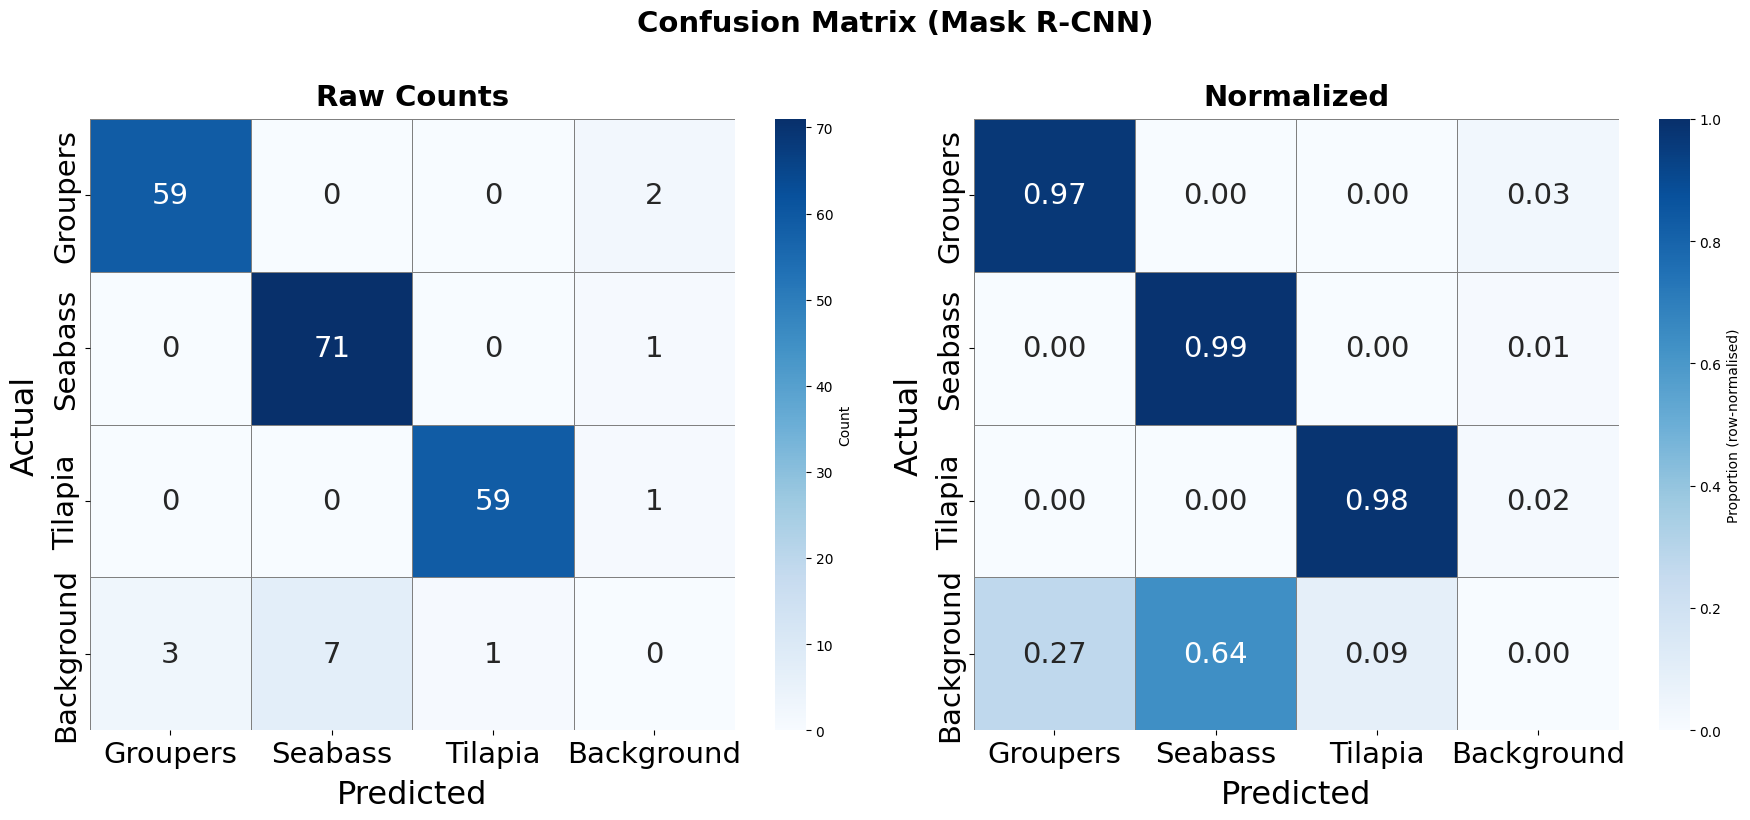

Saved → /home/somel/code/FYP_Project/results/maskrcnn_run6/confusion_matrix_with_bg.png


In [13]:
# CONFUSION MATRIX — Normal & Normalized (With & Without BG)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

def plot_confusion_matrix_variants(cm_full, class_names, save_dir):
    """
    Plots and saves 4 confusion matrix variants:
      1. Without background — raw counts
      2. Without background — normalized
      3. With background    — raw counts
      4. With background    — normalized

    cm_full shape: (num_real + 1, num_real + 1)
      - Rows    = Ground Truth
      - Columns = Predicted
      - Last row/col = Background (FP / FN)
    """

    num_real = len(class_names)         # number of actual classes (no background)
    bg_idx   = num_real                 # index of the background row/col
    labels_with_bg = class_names + ['Background']

    # ── Slice out the two versions ───────────────────────────────────────────
    cm_no_bg = cm_full[:num_real, :num_real].copy()   # real classes only
    cm_with_bg = cm_full.copy()                        # includes background row/col

    # ── Normalise (row-wise so each row sums to 1 = recall per class) ────────
    def row_normalize(cm):
        row_sums = cm.sum(axis=1, keepdims=True).astype(float)
        row_sums[row_sums == 0] = 1  # avoid divide-by-zero
        return cm.astype(float) / row_sums

    cm_no_bg_norm   = row_normalize(cm_no_bg)
    cm_with_bg_norm = row_normalize(cm_with_bg)

    # ── Helper to draw one heatmap ────────────────────────────────────────────
    def draw_heatmap(ax, data, tick_labels, normalized, title):
        if normalized:
            vmin, vmax = 0.0, 1.0
            fmt        = '.2f'
            cbar_label = 'Proportion (row-normalised)'
        else:
            vmin, vmax = 0, data.max() if data.max() > 0 else 1
            fmt        = 'd'
            cbar_label = 'Count'

        sns.heatmap(
            data,
            ax            = ax,
            annot         = True,
            fmt           = fmt,
            cmap          = 'Blues',
            vmin          = vmin,
            vmax          = vmax,
            xticklabels   = tick_labels,
            yticklabels   = tick_labels,
            linewidths    = 0.5,
            linecolor     = 'grey',
            cbar_kws      = {'label': cbar_label},
            annot_kws={'size': 21}
        )

        ax.set_xlabel('Predicted',    fontsize=23, labelpad=8)
        ax.set_ylabel('Actual', fontsize=23, labelpad=8)
        ax.set_title(title,           fontsize=21, fontweight='bold', pad=10)
        ax.tick_params(axis='both', labelsize=21)
        
    # # ══════════════════════════════════════════════════════════════════════════
    # # Figure 1 — Without Background (2 side-by-side subplots)
    # # ══════════════════════════════════════════════════════════════════════════
    # fig1, axes1 = plt.subplots(1, 2, figsize=(18, 8))
    # fig1.suptitle('Confusion Matrix — Without Background (Mask R-CNN)', fontsize=21, fontweight='bold', y=1.02)

    # draw_heatmap(
    #     axes1[0], cm_no_bg, class_names,
    #     normalized = False,
    #     title      = 'Raw Counts'
    # )
    # draw_heatmap(
    #     axes1[1], cm_no_bg_norm, class_names,
    #     normalized = True,
    #     title      = 'Normalized'
    # )

    # fig1.tight_layout()
    # path1 = os.path.join(save_dir, 'confusion_matrix_no_bg.png')
    # fig1.savefig(path1, dpi=150, bbox_inches='tight')
    # plt.show()
    # print(f"Saved → {path1}")

    # ══════════════════════════════════════════════════════════════════════════
    # Figure 2 — With Background (2 side-by-side subplots)
    # ══════════════════════════════════════════════════════════════════════════
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8))
    fig2.suptitle('Confusion Matrix (Mask R-CNN)', fontsize=21, fontweight='bold', y=1.02)

    draw_heatmap(
        axes2[0], cm_with_bg, labels_with_bg,
        normalized = False,
        title      = 'Raw Counts'
    )
    draw_heatmap(
        axes2[1], cm_with_bg_norm, labels_with_bg,
        normalized = True,
        title      = 'Normalized'
    )

    fig2.tight_layout()
    path2 = os.path.join(save_dir, 'confusion_matrix_with_bg.png')
    fig2.savefig(path2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path2}")

# ── Run it ────────────────────────────────────────────────────────────────────
# cm_filtered is already computed in Section 10
# f
plot_confusion_matrix_variants(cm_filtered, filtered_class_names, RESULTS_DIR)

## SECTION 11: IMAGE INFERENCE

In [ ]:
def inference_image(model, image_path, device, conf_threshold=0.5):
    """Run inference on a single image and display results with masks."""
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    image_tensor = F.to_tensor(image).to(device)

    with torch.no_grad():
        outputs = model([image_tensor])[0]

    keep = outputs['scores'] > conf_threshold
    boxes  = outputs['boxes'][keep].cpu().numpy()
    labels = outputs['labels'][keep].cpu().numpy()
    scores = outputs['scores'][keep].cpu().numpy()
    masks  = outputs['masks'][keep].cpu().numpy()

    CLASS_COLORS_RGB = {
        1: (255, 200, 100),
        2: (0,   255,   0),
        3: (255,   0,   0),
        4: (0,   100, 255),
    }
    CLASS_COLORS_HEX = {
        1: '#FFC864',
        2: '#00FF00',
        3: '#FF0000',
        4: '#0064FF',
    }

    overlay = image_np.copy().astype(np.float32)   # ← FIX: was missing

    for box, label, score, mask in zip(boxes, labels, scores, masks):
        color = CLASS_COLORS_RGB.get(label, (200, 200, 200))
        mask_binary = mask[0] > 0.5
        overlay[mask_binary] = overlay[mask_binary] * 0.5 + np.array(color) * 0.5

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(overlay.astype(np.uint8))

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        color = CLASS_COLORS_HEX.get(label, '#C8C8C8')
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        cls_name = MODEL_LABEL_TO_NAME.get(label, f"Class {label}")
        ax.text(x1, y1-5, f'{cls_name}: {score:.2f}', color=color, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axis('off')
    plt.title(f'Mask R-CNN Detection - {os.path.basename(image_path)}')
    plt.tight_layout()
    plt.show()

    return boxes, labels, scores, masks 


def inference_grid(model, images_dir, device, conf_threshold=0.5, num_images=6):
    """
    Run inference on random images and display results in a 2x3 grid with masks.
    """
    import random
    import glob
    
    model.eval()
    
    # Get list of images
    image_paths = glob.glob(os.path.join(images_dir, "*.jpg")) + \
                  glob.glob(os.path.join(images_dir, "*.png")) + \
                  glob.glob(os.path.join(images_dir, "*.jpeg"))
    
    if not image_paths:
        print(f"No images found in {images_dir}")
        return
    
    # Randomly select images (up to num_images)
    selected_images = random.sample(image_paths, min(num_images, len(image_paths)))
    
    # Create 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Class-specific colors: Seabass=Red, Tilapia=Green, Groupers=Blue
    CLASS_COLORS_RGB = {
        1: (255, 200, 100),  # fish-zKdm-lP6L - Orange/Yellow
        2: (0, 255, 0),    # Groupers - Green
        3: (255, 0, 0),      # Seabass - Red
        4: (0, 100, 255),      # Tilapia - Blue
    }
    CLASS_COLORS_HEX = {
        1: '#FFC864',  # fish-zKdm-lP6L - Orange/Yellow
        2: '#00FF00',  # Groupers - Green
        3: '#FF0000',  # Seabass - Red
        4: '#0064FF',  # Tilapia - Blue
    }
    
    for idx, (ax, image_path) in enumerate(zip(axes, selected_images)):
        # Load image
        image = Image.open(image_path).convert('RGB')
        image_np = np.array(image)
        image_tensor = F.to_tensor(image).to(device)
        
        with torch.no_grad():
            outputs = model([image_tensor])[0]
        
        # Filter by confidence
        keep = outputs['scores'] > conf_threshold
        boxes = outputs['boxes'][keep].cpu().numpy()
        labels = outputs['labels'][keep].cpu().numpy()
        scores = outputs['scores'][keep].cpu().numpy()
        masks = outputs['masks'][keep].cpu().numpy()
        
        # Create overlay with masks
        overlay = image_np.copy().astype(np.float32)
        
        for mask, label in zip(masks, labels):
            mask_binary = mask[0] > 0.5
            color = CLASS_COLORS_RGB.get(label, (200, 200, 200))
            overlay[mask_binary] = overlay[mask_binary] * 0.5 + np.array(color) * 0.5
        
        # Display image with masks
        ax.imshow(overlay.astype(np.uint8))
        
        # Draw bounding boxes and labels
        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            color = CLASS_COLORS_HEX.get(label, '#C8C8C8')
            
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=2)
            ax.add_patch(rect)
            
            cls_name = MODEL_LABEL_TO_NAME.get(label, f"Class {label}")
            ax.text(x1, y1-5, f'{cls_name}: {score:.2f}', color=color, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.axis('off')
        ax.set_title(f'{os.path.basename(image_path)}', fontsize=10)
    
    # Handle case where fewer images than grid cells
    for idx in range(len(selected_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Mask R-CNN Detection Results (2x3 Grid)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'inference_grid.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Inference grid saved to: {os.path.join(RESULTS_DIR, 'inference_grid.png')}")


In [ ]:
# Run inference on a single image
image_path = "/home/somel/code/FYP_Project/Dataset/COCO/masking v1.v1-instance-segmentation-1.coco/test/"
inference_grid(model, image_path, device, conf_threshold=0.5)

In [ ]:
#Inference to folder
import os, glob, math, torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from torchvision.transforms import functional as F

def get_next_run(model_name):
    base = f'inference/{model_name}'
    os.makedirs(base, exist_ok=True)
    existing = [int(d.split('_')[1]) for d in os.listdir(base) if d.startswith('run_') and d.split('_')[1].isdigit()]
    next_run = max(existing + [0]) + 1
    run_dir = os.path.join(base, f'run_{next_run}')
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

# 1. Config & Paths
model_type = "fasterrcnn" if "Faster" in MODEL_NAME else "maskrcnn"
run_dir = get_next_run(model_type)
test_image_dir = os.path.join(ROOT_DIR, "test")
image_paths = sorted(glob.glob(os.path.join(test_image_dir, "*.jpg")) + glob.glob(os.path.join(test_image_dir, "*.png")))
print(f"Found {len(image_paths)} images in test set. Starting inference...")

# 2. Batching into 2x3 grids
batch_size = 6
num_grids = math.ceil(len(image_paths) / batch_size)
model.eval()

for grid_idx in range(num_grids):
    start_idx = grid_idx * batch_size
    end_idx = min(start_idx + batch_size, len(image_paths))
    current_batch = image_paths[start_idx:end_idx]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for i, img_path in enumerate(current_batch):
        # Load and transform image
        pil_img = Image.open(img_path).convert("RGB")
        img_tensor = F.to_tensor(pil_img)
        
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])[0]
        
        # Draw on image
        img_draw = np.array(pil_img)
        
        # Bounding Boxes
        for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
            if score > 0.5:
                b = box.cpu().numpy().astype(int)
                name = MODEL_LABEL_TO_NAME.get(label.item(), f"ID {label.item()}")
                cv2.rectangle(img_draw, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 2)
                cv2.putText(img_draw, f"{name} {score:.2f}", (b[0], b[1]-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        # Segmentation Masks (Mask R-CNN Only)
        if 'masks' in prediction and model_type == "maskrcnn":
            for mask, score in zip(prediction['masks'], prediction['scores']):
                if score > 0.5:
                    m = (mask[0].cpu().numpy() > 0.5)
                    color = np.array([0, 255, 0], dtype='uint8')
                    img_draw[m] = cv2.addWeighted(img_draw[m], 0.5, color, 0.5, 0)

        axes[i].imshow(img_draw)
        axes[i].set_title(os.path.basename(img_path), fontsize=10)
        axes[i].axis('off')
    
    # Hide empty subplots if the last batch is < 6
    for i in range(len(current_batch), 6):
        axes[i].axis('off')

    plt.tight_layout()
    save_name = f'inference_grid_{grid_idx + 1}.png'
    plt.savefig(os.path.join(run_dir, save_name), dpi=150, bbox_inches='tight')
    plt.close() # Close to save memory
    if (grid_idx + 1) % 5 == 0 or grid_idx == num_grids - 1:
        print(f"Processed {grid_idx + 1}/{num_grids} grids...")

print(f"\nSuccess! All {num_grids} grids saved to: {run_dir}")

In [ ]:
# Run inference on a single image
image_path = "/home/somel/code/FYP_Project/Dataset/COCO/version2.v7-yolo-version-6--rcnn-version-5-augmented.coco/test/Epinephelus-coioides_123_jpg.rf.d07fc442f8dd08e79d42499e6cdff5c1.jpg"
inference_image(model, image_path, device, conf_threshold=0.5)

## SECTION 12: VIDEO INFERENCE

In [ ]:
def inference_video(model, video_path, output_path, device, conf_threshold=0.5):
    """
    Run inference on a video file and save annotated output with masks.
    """
    model.eval()
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Cannot open video {video_path}")
        return
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    colors = [(255, 107, 107), (78, 205, 196), (69, 183, 209)]
    
    frame_count = 0
    print(f"Processing video: {total_frames} frames at {fps} FPS")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_tensor = F.to_tensor(rgb_frame).to(device)
        
        with torch.no_grad():
            outputs = model([image_tensor])[0]
        
        keep = outputs['scores'] > conf_threshold
        boxes = outputs['boxes'][keep].cpu().numpy()
        labels = outputs['labels'][keep].cpu().numpy()
        scores = outputs['scores'][keep].cpu().numpy()
        masks = outputs['masks'][keep].cpu().numpy()
        
        # Apply mask overlays
        for i, (mask, label) in enumerate(zip(masks, labels)):
            mask_binary = mask[0] > 0.5
            color = colors[(label - 1) % len(colors)]
            frame[mask_binary] = frame[mask_binary] * 0.5 + np.array(color[::-1]) * 0.5  # BGR
        
        # Draw bounding boxes
        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = map(int, box)
            color = colors[(label - 1) % len(colors)]
            
            cv2.rectangle(frame, (x1, y1), (x2, y2), color[::-1], 2)
            
            cls_name = MODEL_LABEL_TO_NAME.get(label, f"Class {label}")
            text = f'{cls_name}: {score:.2f}'
            
            (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1 - text_h - 10), (x1 + text_w, y1), color[::-1], -1)
            cv2.putText(frame, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        cv2.putText(frame, f'Frame: {frame_count}/{total_frames}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        out.write(frame)
        frame_count += 1
        
        if frame_count % 100 == 0:
            print(f"Processed {frame_count}/{total_frames} frames")
    
    cap.release()
    out.release()
    print(f"Video saved to: {output_path}")

In [ ]:
input_video = ""
output_video = ""

inference_video(model, input_video, output_video, device, conf_threshold=0.5)

# OPTIONAL TO RUN

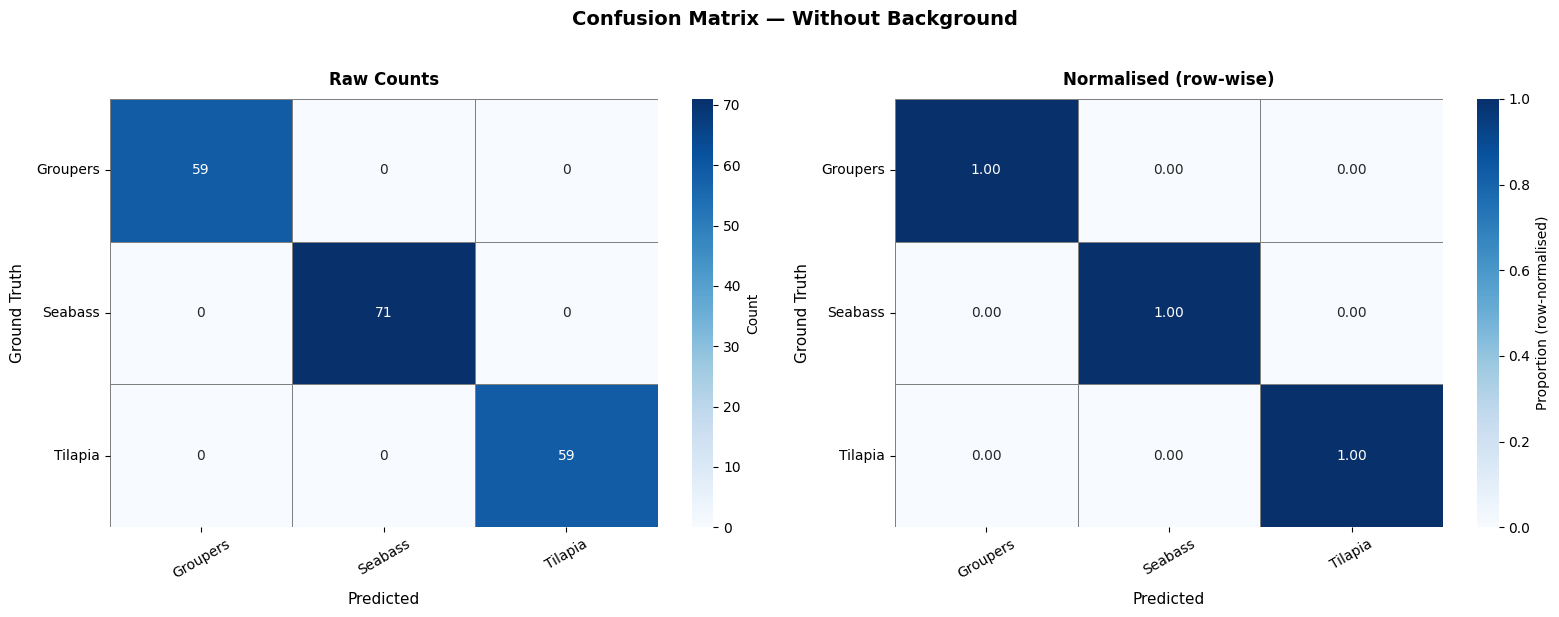

Saved → /home/somel/code/FYP_Project/results/maskrcnn_run6/confusion_matrix_no_bg.png


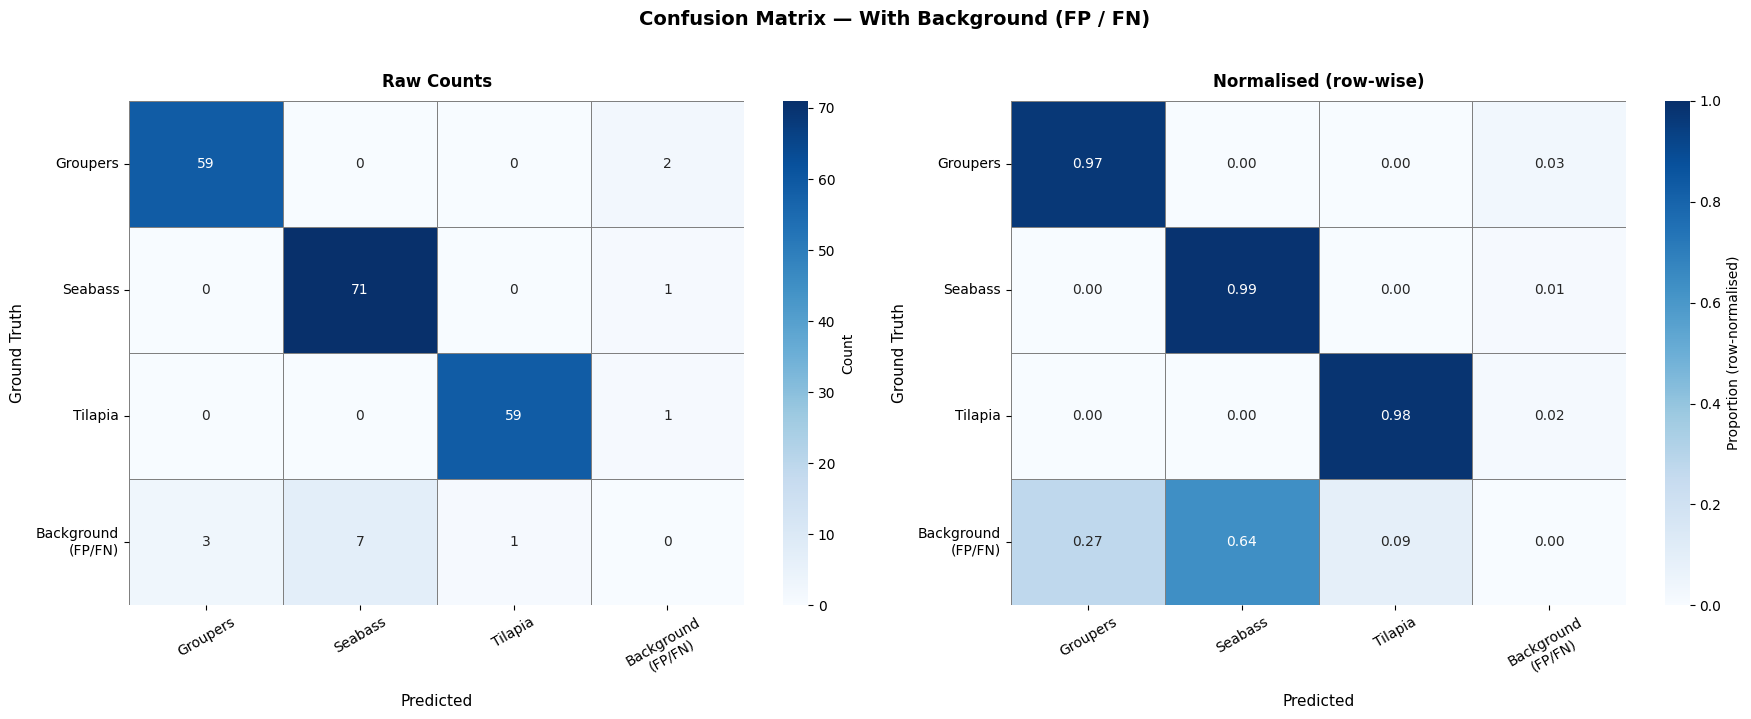

Saved → /home/somel/code/FYP_Project/results/maskrcnn_run6/confusion_matrix_with_bg.png

CM-DERIVED METRICS (no background)
Class           Precision     Recall         F1
-------------------------------------------------------
Groupers           1.0000     1.0000     1.0000
Seabass            1.0000     1.0000     1.0000
Tilapia            1.0000     1.0000     1.0000


In [11]:
# ============================================================
# CONFUSION MATRIX — Normal & Normalized (With & Without BG)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

def plot_confusion_matrix_variants(cm_full, class_names, save_dir):
    """
    Plots and saves 4 confusion matrix variants:
      1. Without background — raw counts
      2. Without background — normalized
      3. With background    — raw counts
      4. With background    — normalized

    cm_full shape: (num_real + 1, num_real + 1)
      - Rows    = Ground Truth
      - Columns = Predicted
      - Last row/col = Background (FP / FN)
    """

    num_real = len(class_names)         # number of actual classes (no background)
    bg_idx   = num_real                 # index of the background row/col
    labels_with_bg = class_names + ['Background\n(FP/FN)']

    # ── Slice out the two versions ───────────────────────────────────────────
    cm_no_bg = cm_full[:num_real, :num_real].copy()   # real classes only
    cm_with_bg = cm_full.copy()                        # includes background row/col

    # ── Normalise (row-wise so each row sums to 1 = recall per class) ────────
    def row_normalize(cm):
        row_sums = cm.sum(axis=1, keepdims=True).astype(float)
        row_sums[row_sums == 0] = 1  # avoid divide-by-zero
        return cm.astype(float) / row_sums

    cm_no_bg_norm   = row_normalize(cm_no_bg)
    cm_with_bg_norm = row_normalize(cm_with_bg)

    # ── Helper to draw one heatmap ────────────────────────────────────────────
    def draw_heatmap(ax, data, tick_labels, normalized, title):
        if normalized:
            vmin, vmax = 0.0, 1.0
            fmt        = '.2f'
            cbar_label = 'Proportion (row-normalised)'
        else:
            vmin, vmax = 0, data.max() if data.max() > 0 else 1
            fmt        = 'd'
            cbar_label = 'Count'

        sns.heatmap(
            data,
            ax            = ax,
            annot         = True,
            fmt           = fmt,
            cmap          = 'Blues',
            vmin          = vmin,
            vmax          = vmax,
            xticklabels   = tick_labels,
            yticklabels   = tick_labels,
            linewidths    = 0.5,
            linecolor     = 'grey',
            cbar_kws      = {'label': cbar_label}
        )

        ax.set_xlabel('Predicted',    fontsize=11, labelpad=8)
        ax.set_ylabel('Ground Truth', fontsize=11, labelpad=8)
        ax.set_title(title,           fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    # ══════════════════════════════════════════════════════════════════════════
    # Figure 1 — Without Background (2 side-by-side subplots)
    # ══════════════════════════════════════════════════════════════════════════
    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
    fig1.suptitle('Confusion Matrix — Without Background', fontsize=14, fontweight='bold', y=1.02)

    draw_heatmap(
        axes1[0], cm_no_bg, class_names,
        normalized = False,
        title      = 'Raw Counts'
    )
    draw_heatmap(
        axes1[1], cm_no_bg_norm, class_names,
        normalized = True,
        title      = 'Normalised (row-wise)'
    )

    fig1.tight_layout()
    path1 = os.path.join(save_dir, 'confusion_matrix_no_bg.png')
    fig1.savefig(path1, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path1}")

    # ══════════════════════════════════════════════════════════════════════════
    # Figure 2 — With Background (2 side-by-side subplots)
    # ══════════════════════════════════════════════════════════════════════════
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
    fig2.suptitle('Confusion Matrix — With Background (FP / FN)', fontsize=14, fontweight='bold', y=1.02)

    draw_heatmap(
        axes2[0], cm_with_bg, labels_with_bg,
        normalized = False,
        title      = 'Raw Counts'
    )
    draw_heatmap(
        axes2[1], cm_with_bg_norm, labels_with_bg,
        normalized = True,
        title      = 'Normalised (row-wise)'
    )

    fig2.tight_layout()
    path2 = os.path.join(save_dir, 'confusion_matrix_with_bg.png')
    fig2.savefig(path2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path2}")

    # ══════════════════════════════════════════════════════════════════════════
    # Console summary — per-class precision & recall derived from the CM
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "="*55)
    print("CM-DERIVED METRICS (no background)")
    print("="*55)
    print(f"{'Class':<14} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-"*55)
    for i, name in enumerate(class_names):
        tp        = cm_no_bg[i, i]
        fp        = cm_no_bg[:, i].sum() - tp   # other GTs predicted as class i
        fn        = cm_no_bg[i, :].sum() - tp   # class i GTs predicted as other
        prec      = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec       = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        print(f"{name:<14} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    print("="*55)


# ── Run it ────────────────────────────────────────────────────────────────────
# cm_filtered is already computed in Section 10
# f
plot_confusion_matrix_variants(cm_filtered, filtered_class_names, RESULTS_DIR)